# HDB Resale Price Model

Building and comparing Linear Regression and XGBoost models to predict HDB resale prices.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

df = pd.read_csv("../data/clean_hdb.csv")
df.head()

,month,town,flat_type,block,street_name,floor_area_sqm,flat_model,lease_commence_date,resale_price,storey_mid,remaining_lease_years
0,2026-04-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,44.0,Improved,1978,290000.0,2.0,50.8
1,2026-04-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,44.0,Improved,1978,303000.0,3.5,50.8
2,2026-04-01,ANG MO KIO,2 ROOM,170,ANG MO KIO AVE 4,45.0,Improved,1986,360000.0,5.5,58.8
3,2026-04-01,ANG MO KIO,3 ROOM,330,ANG MO KIO AVE 1,68.0,New Generation,1981,430000.0,5.5,53.8
4,2026-04-01,ANG MO KIO,3 ROOM,330,ANG MO KIO AVE 1,68.0,New Generation,1981,420000.0,3.5,53.8


## Feature Engineering

Dropping columns not useful for prediction and one-hot encoding categorical columns (town, flat_type, flat_model).
Remaining_lease_years dropped due to perfect multicollinearity with lease_commence_date.

In [3]:
df = df.drop(columns=['month', 'block', 'street_name', 'remaining_lease_years'])
df = pd.get_dummies(df, columns=['town', 'flat_type', 'flat_model'])
print(df.shape)
df.head()

(10000, 58)


,floor_area_sqm,lease_commence_date,resale_price,storey_mid,town_ANG MO KIO,town_BEDOK,town_BISHAN,town_BUKIT BATOK,town_BUKIT MERAH,town_BUKIT PANJANG,...,flat_model_Multi Generation,flat_model_New Generation,flat_model_Premium Apartment,flat_model_Premium Apartment Loft,flat_model_Premium Maisonette,flat_model_Simplified,flat_model_Standard,flat_model_Terrace,flat_model_Type S1,flat_model_Type S2
0,44.0,1978,290000.0,2.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,44.0,1978,303000.0,3.5,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,45.0,1986,360000.0,5.5,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,68.0,1981,430000.0,5.5,True,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,68.0,1981,420000.0,3.5,True,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [4]:
X = df.drop(columns=['resale_price'])
y = df['resale_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (8000, 57)
Test set: (2000, 57)


## Baseline Model - Linear Regression

Starting with Linear Regression as a baseline to benchmark against.

In [5]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression RMSE: ${rmse:,.0f}")
print(f"Linear Regression R²: {r2:.4f}")

Linear Regression RMSE: $75,100
Linear Regression R²: 0.8722


## XGBoost Model

XGBoost builds hundreds of decision trees and combines them, capturing complex non-linear relationships.
Results: RMSE dropped from 75,100 to 50,732 and R2 improved from 0.87 to 0.94 over Linear Regression.

In [6]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost RMSE: ${rmse_xgb:,.0f}")
print(f"XGBoost R²: {r2_xgb:.4f}")

XGBoost RMSE: $50,732
XGBoost R²: 0.9417


In [7]:
import joblib

joblib.dump(xgb_model, '../models/xgb_model.pkl')
print("Model saved!")

Model saved!


## Feature Importance

Town features dominate predictions, reflecting Singapore's location-driven property market.
floor_area_sqm is the strongest non-location predictor, consistent with EDA findings.

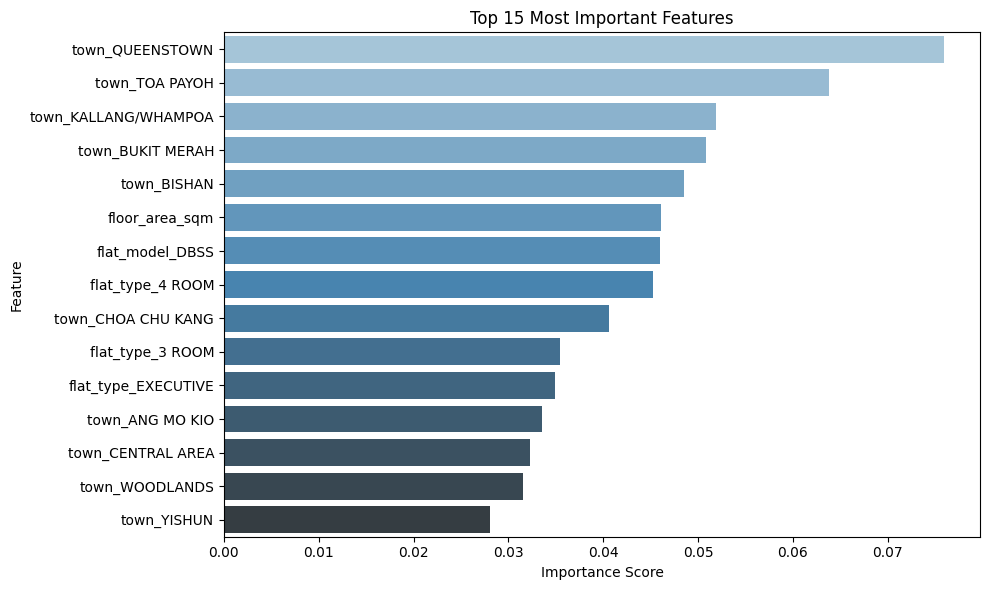

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', hue='feature', legend=False, palette='Blues_d')
plt.title('Top 15 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Cross Validation

5-fold cross validation to verify the model generalises well and isn't overfitting.
Mean R²: 0.9462, Standard deviation: 0.0019 — highly consistent across all splits.

In [10]:
from sklearn.model_selection import cross_val_score

xgb_cv = XGBRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(xgb_cv, X, y, cv=5, scoring='r2')

print(f"R² scores across 5 folds: {scores.round(4)}")
print(f"Mean R²: {scores.mean():.4f}")
print(f"Standard deviation: {scores.std():.4f}")

R² scores across 5 folds: [0.9477 0.9462 0.9437 0.9489 0.9443]
Mean R²: 0.9462
Standard deviation: 0.0019


In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
}

xgb_tuned = XGBRegressor(random_state=42)

grid_search = GridSearchCV(
    xgb_tuned,
    param_grid,
    cv=3,
    scoring='r2',
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best R²: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300}
Best R²: 0.9445


## Hyperparameter Tuning

Used GridSearchCV to test 27 combinations of n_estimators, max_depth and learning_rate.
Best parameters: learning_rate=0.2, max_depth=5, n_estimators=300.
Tuned model improved RMSE from 50,732 to 46,987 and R2 from 0.9417 to 0.9500.
Updated train.py with best parameters so retraining always uses the optimal configuration.

In [12]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Tuned XGBoost RMSE: ${rmse_tuned:,.0f}")
print(f"Tuned XGBoost R²: {r2_tuned:.4f}")
print(f"\nComparison:")
print(f"Default XGBoost  — RMSE: $50,732 | R²: 0.9417")
print(f"Tuned XGBoost    — RMSE: ${rmse_tuned:,.0f} | R²: {r2_tuned:.4f}")

Tuned XGBoost RMSE: $46,987
Tuned XGBoost R²: 0.9500

Comparison:
Default XGBoost  — RMSE: $50,732 | R²: 0.9417
Tuned XGBoost    — RMSE: $46,987 | R²: 0.9500
